# XX. Summary of germination models

## Week 13/2026

_Boyan Mihaylov, MSc Computational Science (UVA/VU)_

This notebook provides a systematic summary of all diffusion-driven germination models in the study. Furthermore, a reparameterisation framework is presented for their simplification.

## 1. Geometric variables

A spore is idealised as a sphere with a radius $r_s$, a surface area $A_s=4\pi r_s^2$ and a volume $V_s=4/3 \pi r_s^3$. The cell wall can be viewed as the outermost shell of this sphere, consisting of two thinner shells: an outer, hydrophobin-rich layer with a thickness $h_\textrm{hp}$ and an inner, polysaccharide-rich layer with a thickness $h_{\textrm{ps}}$.

The volume of the inner cell wall is considered the main compartment of inducer saturation. The total volume can be calculated as

$$
V_{\textrm{ps}}=\frac{4}{3}\pi\left[(r_s-d_{\textrm{hp}})^3-(r_s-d_{\textrm{hp}}-d_{\textrm{ps}})^3\right],
$$

which reflects the subtraction of the protoplast (membrane included) from the internal volume without the outer cell wall. Since the thickness of the hydrophobin layer is determined by the size of the hydrophobin rodlets, it can be considered nearly constant. On the other hand, the spore radius and the inner cell wall may exhibit much larger variations. For this reason, the spore radius $r_s$ can be modelled by a normally distributed random variable $R$ with a mean $\mu_R$ and a standard deviation $\sigma_R$. Similarly, the inner cell wall thickness can be modelled by a random variable $H$ with a mean $\mu_H$ and a standard deviation $\sigma_H$. It is important to consider that the inducer can occupy at most only the vacant fraction of the total volume, which according to studies[1] is approximately 24%. Thus, the expression for the effective inner cell wall volume becomes

$$
V_{\textrm{ps, eff}}=0.24\frac{4}{3}\pi\left[(R-d_{\textrm{hp}})^3-(R-d_{\textrm{hp}}-H)^3\right].
$$

Similarly, the other geometric variables can incorporate the random spore radius:

$$
A_s=4\pi R^2,
$$

$$
V_s=4/3 \pi R^3.
$$

## 2. Main molecular components

Germination is considered to be primarily dependent on two molecular actors - an inhibitor $\textrm{I}$ (e.g. 1-octen-3-ol) and an inducer $\textrm{C}$ (e.g. alanine). There are 4 relevant types of concentration:
- $c_{\textrm{in}}^{\textrm{I}}$ - concentration of inhibitor in the interior side of the cell wall;
- $c_{\textrm{out}}^{\textrm{I}}$ - concentration of inhibitor in the extracellular medium;
- $c_{\textrm{in}}^{\textrm{C}}$ - concentration of inducer in the interior side of the cell wall;
- $c_{\textrm{out}}^{\textrm{C}}$ - concentration of inducer in the extracellular medium.

At inoculation, the interior concentration of inhibitor is defined as

$$
c_{\textrm{in}}^{\textrm{I}}(t=0)=c_0.
$$

Furthermore, any exterior concentration of inhibitor present at inoculation is defined as

$$
c_{\textrm{out}}^{\textrm{I}}(t=0)=c_{\textrm{ex}}^{\textrm{I}}.
$$

In most cases in this study, $c_{\textrm{ex}}^{\textrm{I}}=0$.

The inhibitor molecules strive to equilibrate across the cell wall. Taking into account the density of spores as sources of inhibitor dispersal, the internal inhibitor concentration at any spore over time can be calculated as

$$
c_{\textrm{in}}^{\textrm{I}}(t)=\left[\phi+(1-\phi)e^{-\frac{t}{\tau(1-\phi)}}\right] c_0+(1-\phi)\left(1-e^{-\frac{t}{\tau^{\textrm{I}}(1-\phi)}}\right)c_{\textrm{ex}}^{\textrm{I}}
$$

or simply

$$
c_{\textrm{in}}^{\textrm{I}}(t)=\left[\phi+(1-\phi)e^{-\frac{t}{\tau^{\textrm{I}}(1-\phi)}}\right] c_0
$$

if $c_{\textrm{ex}}^{\textrm{I}}=0$. The two important variables here are the volume fraction

$$
\phi=\rho_sV_s,
$$

with $\rho_s$ representing the number density of spores in a given volume, and

$$
\tau^{\textrm{I}}=\frac{V_s}{P_{\textrm{eff}}^{\textrm{I}}A_s},
$$

which is a characteristic permeation time related to the volume to surface area ratio of the spore and the effective permeation constant $P_{\textrm{eff}}^{\textrm{I}}$ of the inhibitor, valid for the entire cell wall complex. 

A picture of the induction mechanism may be more accurately painted using the available knowledge about carbon-sensitive receptor proteins tethered to the cell membrane. This supports the representation of the inner cell wall as an inducer-soaking compartment, with the outer cell wall being a diffusion-limiting barrier. In the inhibitor case, however, the situation is different. Since there is insufficient evidence for the exact locations where the inhibitor originates and exerts its effect, it is harder to generalise which volumes are relevant for its concentration equilibration and which cell wall layers should be considered in the permeation between spore and medium. Therefore, the full spore volume and area ($V_s$ and $A_s$) are taken as approximate reference and $P_{\textrm{eff}}^{\textrm{I}}$ may account for any number of diffusion-limiting barriers: the cell membrane, the inner cell wall, the hydrophobin layer. In any combination of $M$ of these layers, the permeability is computed through the expression

$$
\frac{1}{P_{\textrm{eff}}^{\textrm{I}}}=\sum_i^M{\frac{1}{P_i^{\textrm{I}}}}.
$$

Contrary to this, the equilibration of inducer concentration over the hydrophobin barrier only takes into account a permeation constant $P_{\textrm{eff}}^{\textrm{C}}$ of the inducer molecule through the rodlet layer and obeys the formula

$$
c_{\textrm{in}}^{\textrm{C}}{(t)}=c_{\textrm{ex}}^{\textrm{C}}(1-e^{-t/\tau^{\textrm{C}}}),
$$

where $c_{\textrm{ex}}^{\textrm{C}}$ is the initial external inducer concentration (considered effectively constant) and

$$
\begin{equation}
\tau^{\textrm{C}}=\frac{V_{\textrm{ps, eff}}}{P_s^{\textrm{C}}A_s},
\end{equation}
$$

i.e. the characteristic permeation time is dependent on the inner cell wall compartment and not on the entire spore volume.

## 3. Germination mechanisms

Under the general assumption that both the release of inhibition and a strong enough inducing signal must be present for germination, the break of dormancy can be expressed as an instantaneous event that depends on a twofold criterion:

$$
c_{\textrm{in}}^{\textrm{I}}(t) < \gamma c_0^{\textrm{I}} \quad \textrm{and} \quad s\left(c_{\textrm{in}}^{\textrm{C}}(t)\right) > \omega.
$$

The first criterion states that germination becomes possible when the internal inhibitor concentration is below a certain fraction $\gamma$ (with $0<\gamma<1$) of its initial concentration. By specifying

$$
c_{\textrm{in}}^{\textrm{I}}(t) = \beta c_0,
$$

where

$$
\beta=\phi+(1-\phi)e^{-\frac{t}{\tau(1-\phi)}},
$$

one can simplify the criterion as

$$
\beta < \gamma.
$$

It is natural to assume that the threshold value $\beta$ is not universal for all spores but rather depends on a complex network of factors, which can be reflected by modelling it as a Normal random variable $X$, with mean $\mu_X$ and standard deviation $\sigma_X$.

The second criterion enables germination when an inducing signal produced by the inducer concentration inside the outer cell wall becomes larger than a certain threshold $\omega$ (with $0<\omega<1$) of the outside concentration (which for simplicity is considered constant). Due to the known mechanisms of ligation to receptor molecules, the inducing effect is not linear with the concentration but can be assumed to follow Michaelis-Menten dynamics:

$$
s\left(c_{\textrm{in}}^{\textrm{C}}(t)\right)=s_{\textrm{max}} \frac{c_{\textrm{in}}^\textrm{C}(t)}{K_s^\textrm{C}+c_{\textrm{in}}^\textrm{C}(t)}
$$

with a saturation level $s_{\textrm{max}}$ (set to $1$ to normalize the signal against the threshold) and a half-saturation constant $K_s^\textrm{C}$.

Such an assumption could not be made for the inhibitor due to lack of evidence, hence its simpler formulation. On the other hand, the inducer condition does not allow analogical cancellations (e.g. of $c_{\textrm{ex}}^{\textrm{C}}$), so we keep the full inequality expression.

Once again, the threshold $\omega$ may be influenced by many factors, so it is best modelled by a Normal random variable $Y$ with mean $\mu_Y$ and standard deviation $\sigma_Y$.

In the simplest case, when the inhibitor and inducer are non-interacting, the probability of a spore germinating at a given time can be expressed as

$$
p(t) = \mathbb{P}{(\beta < X \: \cap \: \psi > Y \: | \: \rho_s, t)}=\int_0^{\infty}{\int_0^{\infty}{\left[1-F_X{(\beta)}\right]\, f_R(r_s) \, F_Y{(s)} \, f_H(d_{\textrm{ps}})d{r_s}}d{d_{\textrm{ps}}}},
$$

where

$$
F_X{(\beta)}=\Phi{\left(\frac{\beta(r_s, t)-\mu_X}{\sigma_X}\right)}
$$

and

$$
F_Y{(s)}=\Phi{\left(\frac{s(K_s^\textrm{C}, r_s, d_{\textrm{ps}}, t)-\mu_Y}{\sigma_Y}\right)}
$$

are cumulative distribution functions,

$$
f_R(r_s) = \frac{1}{\sqrt{2\pi}\sigma_R}\exp{\left(-\frac{(r_s-\mu_R)}{2\sigma_R^2}\right)}
$$

and

$$
f_H(d_{\textrm{ps}}) = \frac{1}{\sqrt{2\pi}\sigma_H}\exp{\left(-\frac{(d_{\textrm{ps}}-\mu_H)}{2\sigma_H^2}\right)}
$$

are Normal probability density functions, and a separate integral is taken over all possible values for the two random variables $R$ and $H$.

A constrain is imposed on all random variable parameters that their standard deviation must not exceed the order of the mean, otherwise they would produce unrealistically wide distributions. Therefore, instead of manipulating the $\sigma$ parameters directly, an exponent parameter $\delta$ is assigned to each random variable distribution, such that

$$
\sigma=\mu e^{-\delta}.
$$

In summary, the free parameters of this model are $P_{\textrm{eff}}^{\textrm{I}}$, $P_s^{\textrm{C}}$, $K_s^\textrm{C}$, $\mu_X$, $\delta_X$, $\mu_Y$ and $\delta_Y$.

## 4. Interactions

The probability expression becomes more complex once interactions between the inhibitor and the inducer come into play. The following interactions are of interest for the models:

- the inhibitor reduces the signal strength

In [2]:
using CUDA, FastGaussQuadrature

# build tensor grid (same as before)
function build_tensor_grid(n::Int, d::Int)
    xs, ws = gausslegendre(n)
    N = n^d
    coords = Array{Float32}(undef, N * d)
    weights = Array{Float32}(undef, N)
    for idx in 0:(N-1)
        base = idx * d
        w = 1f0
        tmp = idx
        for k in 1:d
            ik = (tmp % n) + 1
            tmp ÷= n
            coords[base + k] = Float32(xs[ik])
            w *= Float32(ws[ik])
        end
        weights[idx+1] = w
    end
    return coords, weights, N
end

# GPU-friendly integrand: read coords via flattened indexing
@inline function gpu_f_flat(coords, base::Int32, d::Int32)
    p = 1.0f0
    @inbounds for k in 0:(d-1)
        xi = coords[base + k + 1]   # 1-based Julia indexing on device array
        p *= (1f0 - xi^2)
    end
    return p
end

# kernel: each thread handles one quadrature point
function quad_kernel(coords, weights, out, d::Int32)
    i = (blockIdx().x - 1) * blockDim().x + threadIdx().x
    if i <= length(weights)
        base = Int32((i-1) * d)            # base index (0-based for offset)
        val = gpu_f_flat(coords, base, d)
        out[i] = val * weights[i]
    end
    return
end

function gauss_tensor_gpu(n::Int, d::Int)
    coords_cpu, weights_cpu, N = build_tensor_grid(n, d)
    coords_d = CuArray(coords_cpu)
    weights_d = CuArray(weights_cpu)
    out_d = CUDA.zeros(Float32, N)
    threads = 256
    blocks = cld(N, threads)
    @cuda threads=threads blocks=blocks quad_kernel(coords_d, weights_d, out_d, Int32(d))
    return sum(Array(out_d))
end

# example
println(gauss_tensor_gpu(8, 3))


2.3703697


In [5]:
using CUDA, FastGaussQuadrature

# --- build tensor-product coords & weights (same layout as earlier) ---
function build_tensor_grid(n::Int, d::Int)
    xs, ws = gausslegendre(n)
    N = n^d
    coords = Array{Float32}(undef, N * d)
    weights = Array{Float32}(undef, N)
    for idx in 0:(N-1)
        base = idx * d
        tmp = idx
        w = 1f0
        for k in 1:d
            ik = (tmp % n) + 1
            tmp ÷= n
            coords[base + k] = Float32(xs[ik])
            w *= Float32(ws[ik])
        end
        weights[idx+1] = w
    end
    return coords, weights, N
end

# --- Example integrand: replace body with your param-dependent function ---
@inline function integrand_point(coords, base::Int32, d::Int32, params, pbase::Int32)
    # coords: flattened coords array
    # params: flattened params array (M * param_dim)
    val = 1.0f0
    @inbounds for k in 0:(d-1)
        xi = coords[base + k + 1]
        val *= (1f0 - xi^2)          # example integrand
    end
    # Example param dependence: params[pbase + 1] ... params[pbase+7]
    # incorporate parameters into val as needed. Example multiply by sum(params):
    s = 0f0
    @inbounds for j in 0:6
        s += params[pbase + j + 1]
    end
    return val * (1f0 + 0.001f0 * s)  # example usage
end

# kernel: write per-(point,param) contribution to outbuf
function batch_kernel(coords_chunk, weights_chunk, d::Int32,
                      params_d, param_dim::Int32, outbuf, P::Int32)
    tid = (blockIdx().x-1) * blockDim().x + threadIdx().x
    Ntot = Int32(length(weights_chunk)) * P
    if tid <= Ntot
        pi = Int32((tid - 1) ÷ P)        # 0-based point index in chunk
        param_idx = Int32((tid - 1) % P) # 0-based param index
        base = Int32(pi * d)
        pbase = Int32(param_idx * param_dim)
        val = integrand_point(coords_chunk, base, d, params_d, pbase)
        w = weights_chunk[pi + 1]
        outbuf[tid] = val * w
    end
    return
end

# --- Host orchestration: stream points in chunks ---
function integrate_batched(n::Int, d::Int, params::Array{Float32,2}; chunk_size::Int=4096)
    coords_cpu, weights_cpu, N = build_tensor_grid(n, d)
    P = size(params, 1); param_dim = size(params, 2)
    @assert param_dim == 7
    params_flat = vec(params')                    # row-major flatten (M × param_dim)
    params_d = CuArray(params_flat)
    accum_d = CUDA.zeros(Float32, P)              # final accumulators

    i = 1
    while i <= N
        len = min(chunk_size, N - i + 1)
        coords_chunk = CuArray(@view coords_cpu[(i-1)*d + 1 : (i-1)*d + len*d])
        weights_chunk = CuArray(@view weights_cpu[i : i+len-1])
        P32 = Int32(P)
        total = len * P
        outbuf = CUDA.zeros(Float32, total)       # per-(point,param) contributions
        threads = 256
        blocks = cld(total, threads)
        @cuda threads=threads blocks=blocks batch_kernel(coords_chunk, weights_chunk, Int32(d),
                                                       params_d, Int32(param_dim), outbuf, P32)
        CUDA.synchronize()
        
        # COPY OUTBUF TO HOST AND REDUCE PER-PARAM (fast for moderate chunk_size)
        host_buf = Array(outbuf)               # length = len * P
        host_mat = reshape(host_buf, (P, len)) # P rows, len columns
        # sum across columns -> partial sums per parameter
        partials = sum(host_mat; dims=2)       # returns P×1 array
        accum = Array(accum_d)                 # copy current accum to host
        accum .+= vec(partials)                # update
        accum_d .= CuArray(accum)              # copy back to device accumulators

        i += len
    end

    return Array(accum_d)
end


# --- Example usage ---
# Suppose M=1000 parameter sets, each param_dim=7
M = 1000
params = rand(Float32, M, 7)  # fill with your parameter sets
res = integrate_batched(8, 3, params; chunk_size=4096)
println("Got $(length(res)) integrals")


Got 1000 integrals


In [1]:
using PyPlot
using Revise

Revise.includet("../src/germstats.jl")
Revise.includet("../src/germstats_gpu.jl")
Revise.includet("../src/conversions.jl")

using .GermStats
using .GermStatsGPU
using .Conversions

In [7]:
rho_s = inverse_mL_to_cubic_um(1e5)
t_max = 48*3600 # seconds
times = collect(LinRange(0.0f0, t_max, 1000))

anchor = Dict(
    :Pₛ => 1e-3,
    :Pₛ_cs => 1e-6,
    :μ_γ => 1e-3,
    :σ_γ => 1e-3,
    :neg_δ_γ => 1,
    :μ_ω => 1e-1,
    :σ_ω=> 1e-1,
    :neg_δ_ω => 1,
    :s => 0.5,
    :b => 0.95,
    :μ_ψ => 0.5,
    :σ_ψ => 0.01,
    :K_cC => 0.01,
    :K_cI => 0.01,
    :K_I => 0.01,
    :k_C => 0.1,
    :n => 2,
    :k_I => 1.0
)

def_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05
)


# # Default parameters
# def_params = Dict(
#     :μ_ξ => 2.65,
#     :σ_ξ => 0.3,
#     :c₀_cs => 0.01,
#     :d_hp => 0.01,
#     :μ_κ => 0.2,
#     :σ_κ => 0.05
# )

# param_dict = Dict(
#     :mu_R       => [2.65],
#     :sigma_R    => [0.3],
#     :mu_H       => [0.2],
#     :sigma_H    => [0.05],
#     :c_ex       => [0.01],
#     :P_I        => [1e-3],
#     :P_C        => [1e-6],
#     :mu_X       => [1e-3],
#     :sigma_X    => [1e-3],
#     :mu_Y       => [1e-1],
#     :sigma_Y    => [1e-1],
#     :K_s        => [0.01],
# )

param_dict = Dict(
    :mu_R       => fill(2.65, 1),
    :sigma_R    => fill(0.3, 1),
    :mu_H       => fill(0.2, 1),
    :sigma_H    => fill(0.05, 1),
    :c_ex       => fill(0.01, 1),
    :P_I        => fill(1e-3, 1),
    :P_C        => fill(1e-6, 1),
    :mu_X       => fill(1e-3, 1),
    :sigma_X    => fill(1e-3, 1),
    :mu_Y       => fill(1e-1, 1),
    :sigma_Y    => fill(1e-1, 1),
    :K_s        => fill(0.01, 1),
)

@time germination = compute_germination("independent", rho_s, times, param_dict)
@time germination_2 = compute_germination_response("independent", times, rho_s, merge(anchor, def_params))

  0.009176 seconds (156 allocations: 1.986 MiB)
  0.068104 seconds (27.29 k allocations: 110.596 MiB)


1000-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 3.6599064020928544e-31
 1.512044473652879e-26
 1.0567818316389005e-22
 1.63447125384416e-19
 7.697375202158055e-17
 ⋮
 0.8393410010685132
 0.8393410369472798
 0.8393410726553443
 0.8393411081872612
 0.8393411435472613
 0.8393411787363358
 0.8393412137586247
 0.8393412486087786
 0.8393412832909393
 0.8393413178060708
 0.839341352158226
 0.8393413863421499

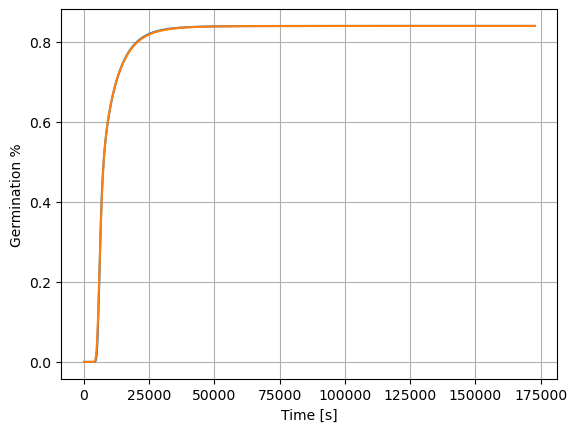

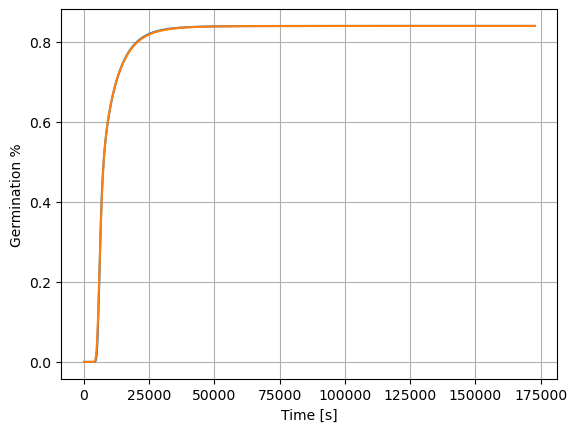

In [3]:
matplotlib.pyplot.close()

fig, ax = subplots()

ax.plot(times, germination[1, :])
ax.plot(times, germination_2)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

## References